# Spatial Sanity Check
Load one geometry parquet file, reconstruct $1024 \times 1024$ grids, and compare I/F against incidence angle.
If dark I/F regions align with high incidence ($i \to 90^\circ$), SPICE-to-DTM alignment is consistent.

In [18]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

geom_dir = Path('../data/04_geometry_tables')
parquet_files = sorted(geom_dir.glob('*_geometry.parquet'))
if not parquet_files:
    raise FileNotFoundError('No geometry parquet files found in ../data/04_geometry_tables')

# Pick the parquet with the most rows so sanity plots use the richest output available.
best_rows = -1
parquet_path = None
df = None
for candidate in parquet_files:
    tmp = pd.read_parquet(candidate)
    if len(tmp) > best_rows:
        best_rows = len(tmp)
        parquet_path = candidate
        df = tmp

print(f'Loaded: {parquet_path.name}')
print(f'Rows: {len(df):,}')
print(f'Columns: {list(df.columns)}')
print(f'Files discovered: {len(parquet_files)}')
if len(df) == 0:
    print('WARNING: all geometry parquet files are empty (0 rows).')

Loaded: FC21B0003931_11223181258F1F_geometry.parquet
Rows: 1,048,576
Columns: ['pixel_x', 'pixel_y', 'iof', 'incidence', 'emission', 'phase']
Files discovered: 3


In [19]:
import numpy as np

def pick_col(dataframe, candidates):
    for col in candidates:
        if col in dataframe.columns:
            return col
    raise KeyError(f'None of these columns found: {candidates}')

iof_col = pick_col(df, ['iof', 'I/F', 'if', 'reflectance'])
inc_col = pick_col(df, ['incidence', 'incidence_deg', 'incidence [deg]', 'i_deg'])

height, width = 1024, 1024
geometry_empty = len(df) == 0

if geometry_empty:
    # Keep notebook runnable and explicit when parquet has no valid intercept rows.
    iof_grid = np.full((height, width), np.nan, dtype=np.float32)
    inc_grid = np.full((height, width), np.nan, dtype=np.float32)
    covered = 0
else:
    if {'pixel_y', 'pixel_x'}.issubset(df.columns):
        # Sparse-safe rebuild: write values to their pixel coordinates and leave missing as NaN.
        iof_grid = np.full((height, width), np.nan, dtype=np.float32)
        inc_grid = np.full((height, width), np.nan, dtype=np.float32)

        px = df['pixel_x'].to_numpy(dtype=int)
        py = df['pixel_y'].to_numpy(dtype=int)
        valid = (px >= 0) & (px < width) & (py >= 0) & (py < height)

        iof_grid[py[valid], px[valid]] = df[iof_col].to_numpy(dtype=np.float32)[valid]
        inc_grid[py[valid], px[valid]] = df[inc_col].to_numpy(dtype=np.float32)[valid]
    else:
        # Dense fallback for legacy files without pixel coordinates.
        expected = height * width
        if len(df) != expected:
            raise ValueError(
                f"Parquet has {len(df)} rows without pixel_x/pixel_y; cannot reshape to 1024x1024."
            )
        iof_grid = df[iof_col].to_numpy(dtype=np.float32).reshape(height, width)
        inc_grid = df[inc_col].to_numpy(dtype=np.float32).reshape(height, width)

    covered = np.isfinite(inc_grid).sum()

print(f'Pixels with geometry: {covered:,} / {height*width:,} ({covered/(height*width):.1%})')

Pixels with geometry: 1,048,576 / 1,048,576 (100.0%)


## Opposition Effect Check (Li et al. 2013 style)
Combine all valid pixels from the three geometry parquet files, then inspect how I/F varies with phase angle using a 2D density plot and a 1 degree binned mean trend line.

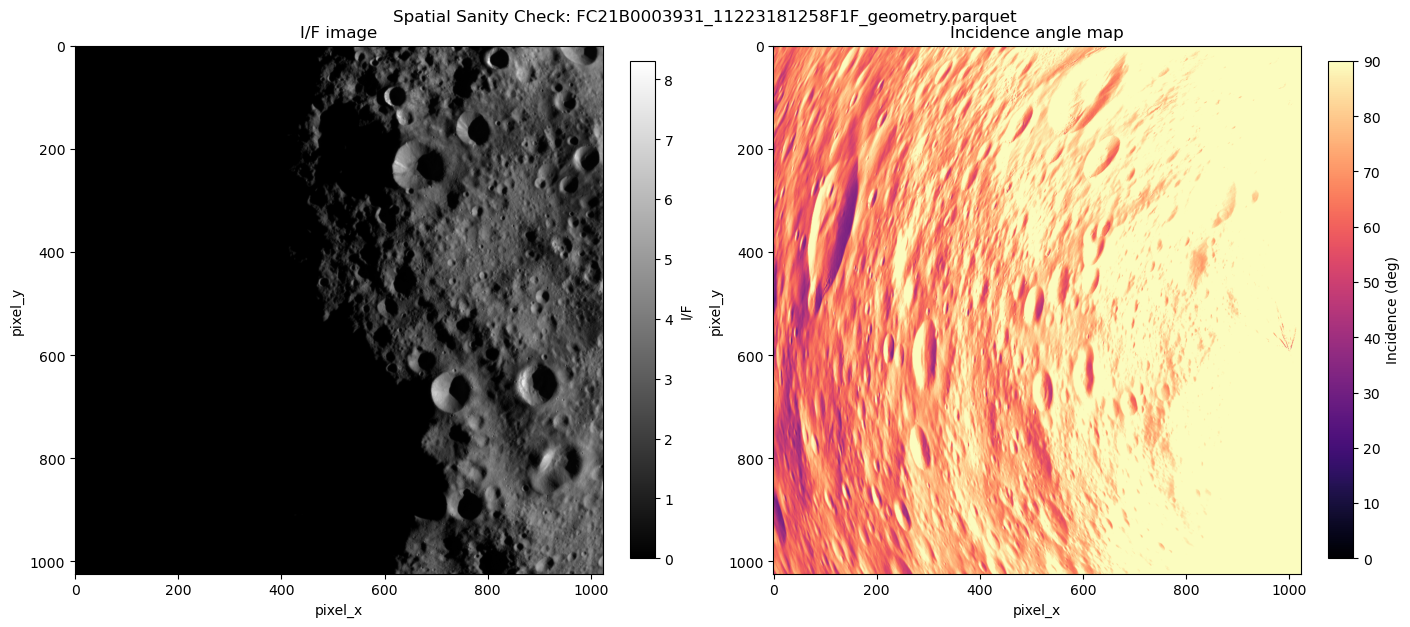

Check: dark I/F shadows should line up with high-incidence areas (near 90 deg).


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axes[0].imshow(iof_grid, cmap='gray', origin='upper')
axes[0].set_title('I/F image')
axes[0].set_xlabel('pixel_x')
axes[0].set_ylabel('pixel_y')
cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label('I/F')

im1 = axes[1].imshow(inc_grid, cmap='magma', origin='upper', vmin=0, vmax=90)
axes[1].set_title('Incidence angle map')
axes[1].set_xlabel('pixel_x')
axes[1].set_ylabel('pixel_y')
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label('Incidence (deg)')

title_suffix = ' (EMPTY GEOMETRY TABLE)' if geometry_empty else ''
plt.suptitle(f'Spatial Sanity Check: {parquet_path.name}{title_suffix}', y=1.02)
plt.show()

if geometry_empty:
    print('No geometry values available to compare yet. Re-run geometry generation for this image.')
else:
    print('Check: dark I/F shadows should line up with high-incidence areas (near 90 deg).')

Combined valid pixels: 2,601,750
Phase range: 77.075 to 84.527 deg
I/F range: 0.00087 to 8.88404


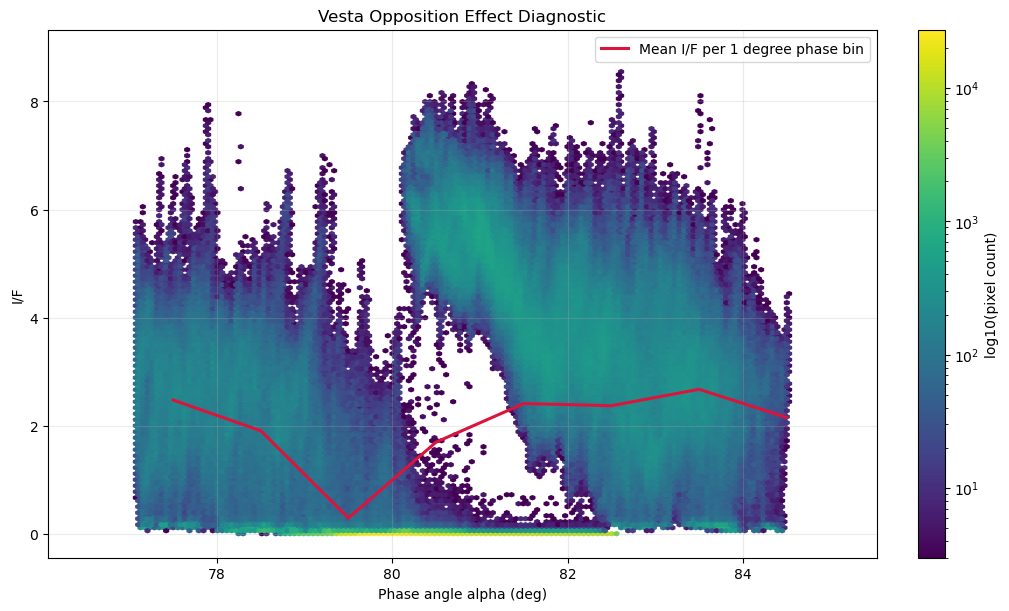

Not enough low-phase bins (<=10 deg) for a strong opposition-slope check.


In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

geom_dir = Path('../data/04_geometry_tables')
parquet_paths = sorted(geom_dir.glob('*_geometry.parquet'))
if len(parquet_paths) < 3:
    raise FileNotFoundError(f'Expected 3 geometry parquet files, found {len(parquet_paths)} in {geom_dir}')

frames = []
for p in parquet_paths:
    dfi = pd.read_parquet(p, columns=['iof', 'phase'])
    # Keep only physically meaningful, finite values.
    dfi = dfi[np.isfinite(dfi['iof']) & np.isfinite(dfi['phase'])]
    dfi = dfi[(dfi['iof'] > 0.0) & (dfi['phase'] >= 0.0) & (dfi['phase'] <= 180.0)]
    dfi = dfi.copy()
    dfi['source'] = p.stem
    frames.append(dfi)

df_all = pd.concat(frames, ignore_index=True)
print(f'Combined valid pixels: {len(df_all):,}')
print(f'Phase range: {df_all.phase.min():.3f} to {df_all.phase.max():.3f} deg')
print(f'I/F range: {df_all.iof.min():.5f} to {df_all.iof.max():.5f}')

# 1 degree phase bins and mean I/F trend.
df_all['phase_bin_deg'] = np.floor(df_all['phase']).astype(int)
trend = (
    df_all.groupby('phase_bin_deg', as_index=False)
    .agg(mean_iof=('iof', 'mean'), n=('iof', 'size'))
    .sort_values('phase_bin_deg')
)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

hb = ax.hexbin(
    df_all['phase'],
    df_all['iof'],
    gridsize=140,
    mincnt=3,
    bins='log',
    cmap='viridis',
)
cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('log10(pixel count)')

ax.plot(
    trend['phase_bin_deg'] + 0.5,
    trend['mean_iof'],
    color='crimson',
    linewidth=2.2,
    label='Mean I/F per 1 degree phase bin',
)

ax.set_title('Vesta Opposition Effect Diagnostic')
ax.set_xlabel('Phase angle alpha (deg)')
ax.set_ylabel('I/F')
ax.set_xlim(max(0, df_all['phase'].min() - 1), min(180, df_all['phase'].max() + 1))
ax.grid(alpha=0.25)
ax.legend(loc='best')
plt.show()

low_mask = trend['phase_bin_deg'] <= 10
if low_mask.sum() > 2:
    m, b = np.polyfit(trend.loc[low_mask, 'phase_bin_deg'], trend.loc[low_mask, 'mean_iof'], 1)
    print(f'Near-opposition slope (0-10 deg): {m:.6f} I/F per degree')
    if m < 0:
        print('PASS: Mean I/F decreases with phase; brightness rises toward opposition.')
    else:
        print('CHECK: Trend near opposition is not decreasing; inspect bins and coverage.')
else:
    print('Not enough low-phase bins (<=10 deg) for a strong opposition-slope check.')

## Disk-Function Correction: Lommel-Seeliger
Apply a Lommel-Seeliger correction to reduce topographic illumination effects and isolate intrinsic regolith reflectance.
Formula used: $R_{LS} = (I/F) \times (\cos i + \cos e) / \cos i$, with angles converted to radians.

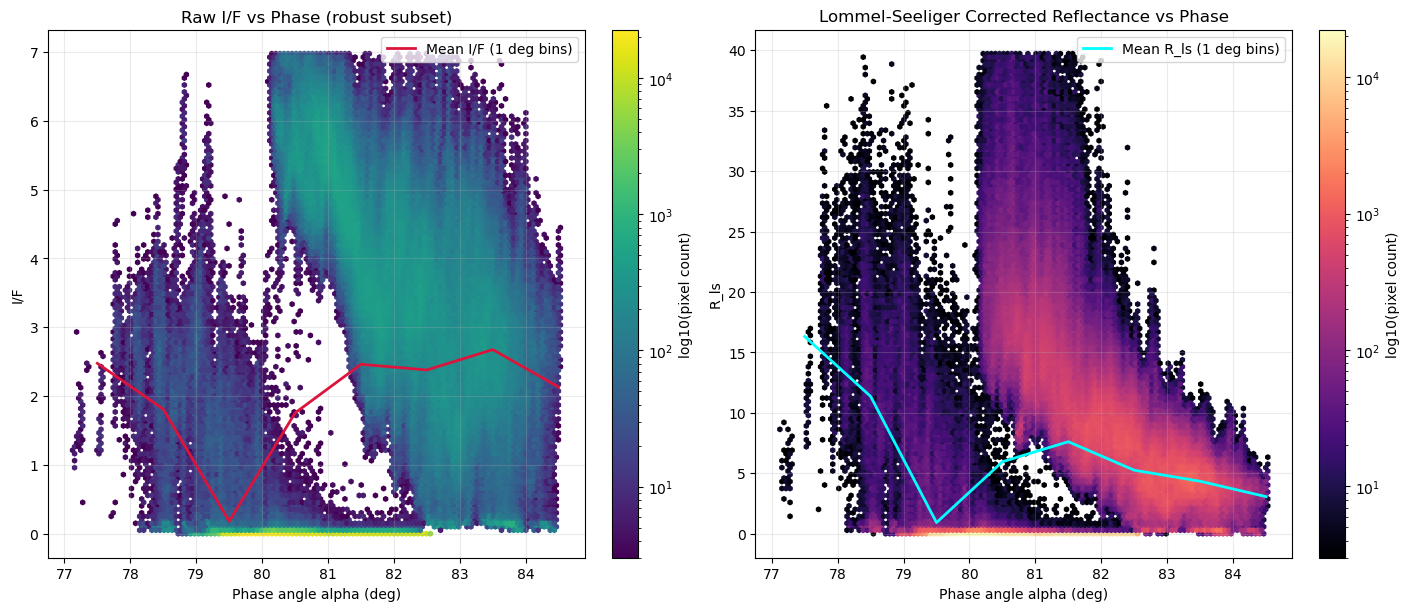

Pixels before LS filters: 1,956,628
Pixels used in robust plot: 1,938,147
Phase coverage: 77.123 to 84.527 deg
Median per-bin scatter (I/F):  1.276892
Median per-bin scatter (R_ls): 5.897079
Tightening ratio R_ls/I/F:      4.6183 (lower is tighter)


In [23]:
# Load all valid pixels needed for disk-function correction
geom_dir = Path('../data/04_geometry_tables')
parquet_paths = sorted(geom_dir.glob('*_geometry.parquet'))
if len(parquet_paths) < 3:
    raise FileNotFoundError(f'Expected 3 geometry parquet files, found {len(parquet_paths)} in {geom_dir}')

frames_ls = []
for p in parquet_paths:
    dfi = pd.read_parquet(p, columns=['iof', 'phase', 'incidence', 'emission'])
    dfi = dfi[np.isfinite(dfi['iof']) & np.isfinite(dfi['phase']) & np.isfinite(dfi['incidence']) & np.isfinite(dfi['emission'])]
    dfi = dfi[(dfi['iof'] > 0.0) & (dfi['phase'] >= 0.0) & (dfi['phase'] <= 180.0)]
    frames_ls.append(dfi)

df_ls = pd.concat(frames_ls, ignore_index=True)

# Convert angles (deg -> rad) and compute cosines.
i_rad = np.deg2rad(df_ls['incidence'].to_numpy(dtype=np.float64))
e_rad = np.deg2rad(df_ls['emission'].to_numpy(dtype=np.float64))
mu0 = np.cos(i_rad)
mu = np.cos(e_rad)

# Stability cuts: remove limb/grazing illumination where LS correction blows up.
# These cuts preserve physically meaningful disk-function behavior.
valid_geom = (
    (mu0 > 0.10) & (mu > 0.0)
    & (df_ls['incidence'].to_numpy() < 84.0)
    & (df_ls['emission'].to_numpy() < 84.0)
)
df_ls = df_ls.loc[valid_geom].copy()
mu0 = mu0[valid_geom]
mu = mu[valid_geom]

# Lommel-Seeliger corrected reflectance.
df_ls['R_ls'] = df_ls['iof'].to_numpy(dtype=np.float64) * (mu0 + mu) / mu0
df_ls = df_ls[np.isfinite(df_ls['R_ls']) & (df_ls['R_ls'] > 0.0)]

# Remove extreme tails for visualization/statistics robustness.
iof_hi = np.quantile(df_ls['iof'], 0.995)
rls_hi = np.quantile(df_ls['R_ls'], 0.995)
df_plot = df_ls[(df_ls['iof'] <= iof_hi) & (df_ls['R_ls'] <= rls_hi)].copy()

# 1 degree phase bins for trend overlays.
df_plot['phase_bin_deg'] = np.floor(df_plot['phase']).astype(int)
trend_iof = (
    df_plot.groupby('phase_bin_deg', as_index=False)
    .agg(mean_iof=('iof', 'mean'), iof_std=('iof', 'std'), n=('iof', 'size'))
    .sort_values('phase_bin_deg')
)
trend_rls = (
    df_plot.groupby('phase_bin_deg', as_index=False)
    .agg(mean_rls=('R_ls', 'mean'), rls_std=('R_ls', 'std'), n=('R_ls', 'size'))
    .sort_values('phase_bin_deg')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

hb0 = axes[0].hexbin(
    df_plot['phase'],
    df_plot['iof'],
    gridsize=120,
    mincnt=3,
    bins='log',
    cmap='viridis',
)
axes[0].plot(trend_iof['phase_bin_deg'] + 0.5, trend_iof['mean_iof'], color='crimson', lw=2.0, label='Mean I/F (1 deg bins)')
axes[0].set_title('Raw I/F vs Phase (robust subset)')
axes[0].set_xlabel('Phase angle alpha (deg)')
axes[0].set_ylabel('I/F')
axes[0].grid(alpha=0.25)
axes[0].legend(loc='best')
cbar0 = fig.colorbar(hb0, ax=axes[0])
cbar0.set_label('log10(pixel count)')

hb1 = axes[1].hexbin(
    df_plot['phase'],
    df_plot['R_ls'],
    gridsize=120,
    mincnt=3,
    bins='log',
    cmap='magma',
)
axes[1].plot(trend_rls['phase_bin_deg'] + 0.5, trend_rls['mean_rls'], color='cyan', lw=2.0, label='Mean R_ls (1 deg bins)')
axes[1].set_title('Lommel-Seeliger Corrected Reflectance vs Phase')
axes[1].set_xlabel('Phase angle alpha (deg)')
axes[1].set_ylabel('R_ls')
axes[1].grid(alpha=0.25)
axes[1].legend(loc='best')
cbar1 = fig.colorbar(hb1, ax=axes[1])
cbar1.set_label('log10(pixel count)')

plt.show()

# Quantify tightening by median per-bin scatter ratio.
joined = trend_iof.merge(trend_rls, on=['phase_bin_deg', 'n'], how='inner')
median_iof_std = np.nanmedian(joined['iof_std'])
median_rls_std = np.nanmedian(joined['rls_std'])
tightening_ratio = median_rls_std / median_iof_std if np.isfinite(median_iof_std) and median_iof_std > 0 else np.nan

print(f'Pixels before LS filters: {len(df_ls):,}')
print(f'Pixels used in robust plot: {len(df_plot):,}')
print(f'Phase coverage: {df_plot.phase.min():.3f} to {df_plot.phase.max():.3f} deg')
print(f'Median per-bin scatter (I/F):  {median_iof_std:.6f}')
print(f'Median per-bin scatter (R_ls): {median_rls_std:.6f}')
print(f'Tightening ratio R_ls/I/F:      {tightening_ratio:.4f} (lower is tighter)')

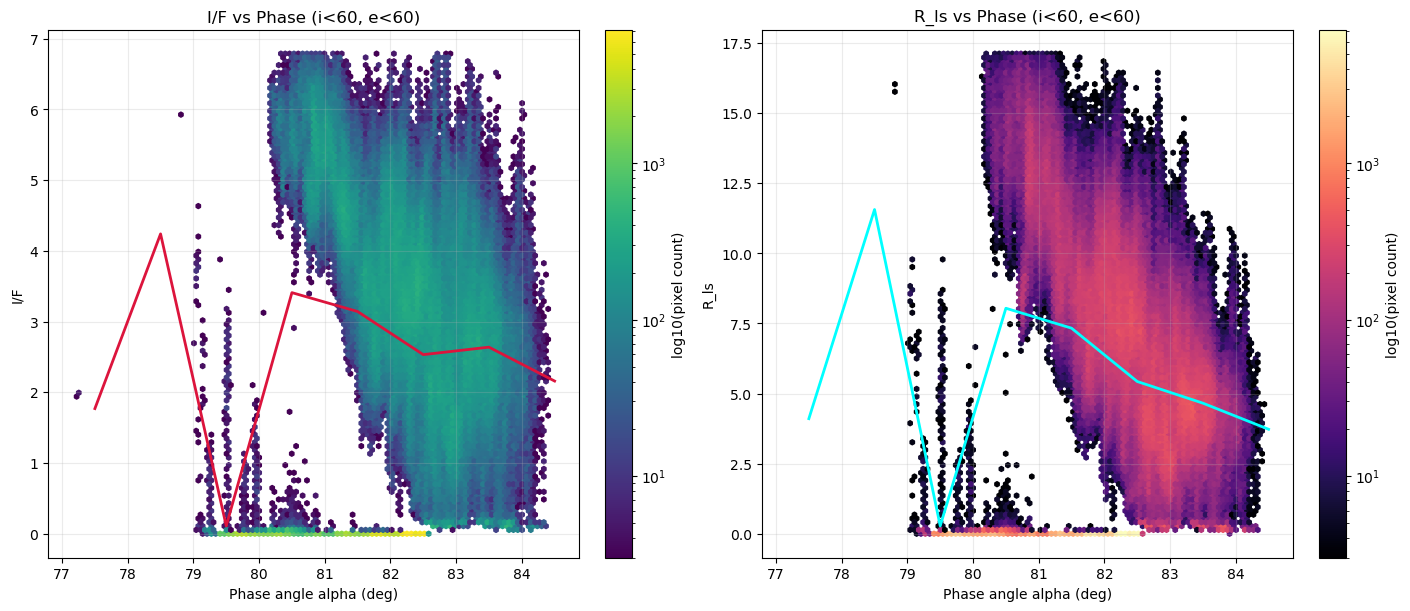

Subset pixels before trim: 702,250
Subset pixels in robust plot: 697,108
Subset phase range: 77.156 to 84.435 deg
Subset median per-bin scatter (I/F):  1.413176
Subset median per-bin scatter (R_ls): 2.930922
Subset tightening ratio R_ls/I/F:      2.0740 (lower is tighter)


In [24]:
# Strict subset check: incidence < 60 deg and emission < 60 deg
subset = df_ls[(df_ls['incidence'] < 60.0) & (df_ls['emission'] < 60.0)].copy()

if subset.empty:
    print('No pixels satisfy i<60 and e<60 in the current dataset.')
else:
    # Robust trimming for visualization and dispersion statistics
    iof_hi_sub = np.quantile(subset['iof'], 0.995)
    rls_hi_sub = np.quantile(subset['R_ls'], 0.995)
    subset_plot = subset[(subset['iof'] <= iof_hi_sub) & (subset['R_ls'] <= rls_hi_sub)].copy()

    subset_plot['phase_bin_deg'] = np.floor(subset_plot['phase']).astype(int)
    trend_iof_sub = (
        subset_plot.groupby('phase_bin_deg', as_index=False)
        .agg(mean_iof=('iof', 'mean'), iof_std=('iof', 'std'), n=('iof', 'size'))
        .sort_values('phase_bin_deg')
    )
    trend_rls_sub = (
        subset_plot.groupby('phase_bin_deg', as_index=False)
        .agg(mean_rls=('R_ls', 'mean'), rls_std=('R_ls', 'std'), n=('R_ls', 'size'))
        .sort_values('phase_bin_deg')
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    hb0 = axes[0].hexbin(
        subset_plot['phase'], subset_plot['iof'],
        gridsize=110, mincnt=3, bins='log', cmap='viridis'
    )
    axes[0].plot(trend_iof_sub['phase_bin_deg'] + 0.5, trend_iof_sub['mean_iof'], color='crimson', lw=2.0)
    axes[0].set_title('I/F vs Phase (i<60, e<60)')
    axes[0].set_xlabel('Phase angle alpha (deg)')
    axes[0].set_ylabel('I/F')
    axes[0].grid(alpha=0.25)
    fig.colorbar(hb0, ax=axes[0]).set_label('log10(pixel count)')

    hb1 = axes[1].hexbin(
        subset_plot['phase'], subset_plot['R_ls'],
        gridsize=110, mincnt=3, bins='log', cmap='magma'
    )
    axes[1].plot(trend_rls_sub['phase_bin_deg'] + 0.5, trend_rls_sub['mean_rls'], color='cyan', lw=2.0)
    axes[1].set_title('R_ls vs Phase (i<60, e<60)')
    axes[1].set_xlabel('Phase angle alpha (deg)')
    axes[1].set_ylabel('R_ls')
    axes[1].grid(alpha=0.25)
    fig.colorbar(hb1, ax=axes[1]).set_label('log10(pixel count)')

    plt.show()

    joined_sub = trend_iof_sub.merge(trend_rls_sub, on=['phase_bin_deg', 'n'], how='inner')
    med_iof_sub = np.nanmedian(joined_sub['iof_std'])
    med_rls_sub = np.nanmedian(joined_sub['rls_std'])
    ratio_sub = med_rls_sub / med_iof_sub if np.isfinite(med_iof_sub) and med_iof_sub > 0 else np.nan

    print(f'Subset pixels before trim: {len(subset):,}')
    print(f'Subset pixels in robust plot: {len(subset_plot):,}')
    print(f'Subset phase range: {subset_plot.phase.min():.3f} to {subset_plot.phase.max():.3f} deg')
    print(f'Subset median per-bin scatter (I/F):  {med_iof_sub:.6f}')
    print(f'Subset median per-bin scatter (R_ls): {med_rls_sub:.6f}')
    print(f'Subset tightening ratio R_ls/I/F:      {ratio_sub:.4f} (lower is tighter)')

In [ ]:
# Spatial sanity check for a specific image: FC21B0003932_11223181943F1F
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

parquet_path = Path('../data/04_geometry_tables/FC21B0003932_11223181943F1F_geometry.parquet')
if not parquet_path.exists():
    raise FileNotFoundError(f'Missing parquet: {parquet_path}')

df_fc = pd.read_parquet(parquet_path)
print(f'Loaded {parquet_path.name} with {len(df_fc):,} rows')

h, w = 1024, 1024
iof_grid = np.full((h, w), np.nan, dtype=np.float32)
inc_grid = np.full((h, w), np.nan, dtype=np.float32)

# Rebuild from sparse flat table using pixel indices when present.
if {'pixel_x', 'pixel_y'}.issubset(df_fc.columns):
    px = df_fc['pixel_x'].to_numpy(dtype=int)
    py = df_fc['pixel_y'].to_numpy(dtype=int)
    valid = (px >= 0) & (px < w) & (py >= 0) & (py < h)
    iof_grid[py[valid], px[valid]] = df_fc['iof'].to_numpy(dtype=np.float32)[valid]
    inc_grid[py[valid], px[valid]] = df_fc['incidence'].to_numpy(dtype=np.float32)[valid]
else:
    expected = h * w
    if len(df_fc) != expected:
        raise ValueError(f'No pixel coordinates and row count={len(df_fc)} cannot reshape to 1024x1024.')
    iof_grid = df_fc['iof'].to_numpy(dtype=np.float32).reshape(h, w)
    inc_grid = df_fc['incidence'].to_numpy(dtype=np.float32).reshape(h, w)

# Deep-space pixels (NaN) shown in black to avoid scaling artifacts.
iof_ma = np.ma.masked_invalid(iof_grid)
inc_ma = np.ma.masked_invalid(inc_grid)

iof_cmap = plt.cm.get_cmap('gray').copy()
iof_cmap.set_bad('black')
inc_cmap = plt.cm.get_cmap('magma').copy()
inc_cmap.set_bad('black')

iof_vmax = np.nanpercentile(iof_grid, 99)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axes[0].imshow(iof_ma, cmap=iof_cmap, origin='upper', vmin=0.0, vmax=iof_vmax)
axes[0].set_title('FC21B0003932 I/F Image')
axes[0].set_xlabel('pixel_x')
axes[0].set_ylabel('pixel_y')

im1 = axes[1].imshow(inc_ma, cmap=inc_cmap, origin='upper')
axes[1].set_title('FC21B0003932 Incidence Angle Map')
axes[1].set_xlabel('pixel_x')
axes[1].set_ylabel('pixel_y')
cbar = fig.colorbar(im1, ax=axes[1])
cbar.set_label('Incidence (deg)')

plt.show()

covered = np.isfinite(inc_grid).sum()
print(f'Valid asteroid pixels: {covered:,} / {h*w:,} ({covered/(h*w):.1%})')
print('Deep-space pixels are masked in black.')